# 04 — Auditoria dos textos de checagem

Objetivo: verificar se o classificador aprende a alegação ou pistas editoriais de uma checagem concluída. Rótulos originais: 0 = Fake, 1 = Real. Termos suspeitos são sinais de triagem, não prova automática de vazamento.

O treinamento exploratório dos notebooks 02 e 03 não exige revisão integral. A ficha data/audit/v1_revisao_texto_autor.csv registra separadamente aprovar, excluir e revisar. Revisar significa que a triagem foi preenchida, mas a adequação da entrada não foi confirmada. Não equivale a aprovação nem a registro inválido.

A revisão contextual com fonte pode preencher título e corpo aprovados, justificativa, revisor e procedência. Não altere IDs, hashes ou rótulos. Autor aprovado identifica a autoria original; quando desconhecida, permanece vazio. Os campos candidatos são sugestões de extração, não textos aprovados. As poucas entradas aprovadas não substituem uma base representativa.

A ficha completa foi preenchida com triagem em 08/10/2026. Isso não constitui leitura contextual integral de todos os textos nem consulta a todas as fontes. Ela não é aplicada automaticamente ao treinamento exploratório. Os gráficos abaixo mostram somente IDs do desenvolvimento. A ficha completa abrange também os registros reservados; não use métricas do teste para orientar decisões de auditoria.


In [1]:
from pathlib import Path
import sys
for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    module_dir = base / "notebooks/v2_validacao_externa"
    if (module_dir / "pipeline_utils.py").is_file():
        sys.path.insert(0, str(module_dir))
        break
else:
    raise FileNotFoundError("Execute dentro do projeto.")
from pipeline_utils import (project_root, compose_text, normalize_text, validate_labels,
                            sha256_file, load_bundle, LABEL_NAMES, SCHEMA_VERSION, MODEL_RELATIVE)
ROOT = project_root()
DATA_DIR = ROOT / "notebooks/v2_validacao_externa/data/processed/texto_completo_v1"
import re
from urllib.parse import urlparse
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

raw = pd.read_excel(ROOT / "data/FakeRecogna.xlsx")
required = {"Titulo", "Noticia", "Classe", "URL"}
if not required.issubset(raw.columns):
    raise ValueError(f"Colunas ausentes: {required - set(raw.columns)}")
raw = raw.dropna(subset=["Noticia", "Classe"]).copy()
raw["label"] = validate_labels(raw.Classe)
raw["texto"] = compose_text(raw)
raw["normalizado"] = raw.texto.map(normalize_text)
raw = raw[raw.normalizado.ne("")].copy()
raw["id_original"] = raw.index
conflicts = raw.groupby("normalizado").label.nunique()
display(raw[raw.normalizado.isin(conflicts[conflicts.gt(1)].index)])
if conflicts.gt(1).any():
    raise ValueError("Resolva conflitos de rótulos antes da investigação.")
print("Duplicatas normalizadas:", int(raw.normalizado.duplicated().sum()))
raw = raw.drop_duplicates("normalizado")
development, reserved = train_test_split(raw, test_size=0.2, stratify=raw.label, random_state=42)
audit = development.copy()
print("Amostras para auditoria:", len(audit), "Reservadas:", len(reserved))


,Titulo,Subtitulo,Noticia,Categoria,Data,Autor,URL,Classe,label,texto,normalizado,id_original


Duplicatas normalizadas: 0
Amostras para auditoria: 9521 Reservadas: 2381


## 1. Pistas editoriais e fontes
Conte ocorrências por classe, por título/corpo e por domínio. Revise se o texto contém uma conclusão posterior à checagem, citação da alegação ou uso legítimo do termo. A URL serve para auditoria e agrupamento, não entra como atributo no classificador.

In [2]:
PATTERN = r"(?i)\b(?:boatos?|fals[oa]s?|fake(?:\s+news)?|enganos[oa]s?|checagem|desmentid[oa]s?|montagem)\b"
for column in ["Titulo", "Noticia", "texto"]:
    audit[f"pista_{column}"] = audit[column].fillna("").astype(str).str.contains(PATTERN, regex=True)
audit["dominio"] = audit.URL.fillna("").map(lambda u: urlparse(str(u)).netloc.lower().removeprefix("www."))
display(audit.groupby("label")[["pista_Titulo", "pista_Noticia", "pista_texto"]].agg(["sum", "mean", "count"]))
tabela_dominios = pd.crosstab(audit.dominio, audit.label).rename(columns={0: "Fake (0)", 1: "Real (1)"})
display(tabela_dominios.sort_values("Fake (0)", ascending=False).head(30))
display(pd.crosstab(audit.dominio, audit.label, normalize="index").head(30))
if "Categoria" in audit:
    audit["categoria_normalizada"] = audit.Categoria.fillna("sem categoria").astype(str).str.strip().str.casefold()
    display(pd.crosstab(audit.categoria_normalizada, audit.label))


pista_Titulo                 pista_Noticia                 pista_texto  \
               sum      mean count           sum      mean count         sum   
label                                                                          
0             3230  0.678571  4760           915  0.192227  4760        3390   
1               32  0.006721  4761            94  0.019744  4761         102   

                       
           mean count  
label                  
0      0.712185  4760  
1      0.021424  4761

label,Fake (0),Real (1)
dominio,,
boatos.org,1980,0
g1.globo.com,950,879
e-farsas.com,652,0
noticias.uol.com.br,472,2734
checamos.afp.com,395,0
projetocomprova.com.br,311,0
entretenimento.uol.com.br,0,54
educacao.uol.com.br,0,33
economia.uol.com.br,0,263


label,0,1
dominio,,
boatos.org,1.000000,0.000000
checamos.afp.com,1.000000,0.000000
e-farsas.com,1.000000,0.000000
economia.uol.com.br,0.000000,1.000000
educacao.uol.com.br,0.000000,1.000000
entretenimento.uol.com.br,0.000000,1.000000
extra.globo.com,0.000000,1.000000
g1.globo.com,0.519410,0.480590
gov.br,0.000000,1.000000


label,0,1
categoria_normalizada,,
brasil,655,56
ciência,155,334
entretenimento,1136,0
mundo,437,4
política,1456,1711
saúde,921,2656


## Gráficos da triagem automática

Os gráficos usam somente o conjunto de desenvolvimento definido acima. **Pista editorial não equivale a contaminação confirmada.** Percentuais são calculados dentro de cada classe/fonte, com suporte mostrado para contextualizar os resultados. Não representam métricas de um modelo. As figuras são exibidas ao executar esta seção; ative a exportação para salvar PNGs e SVGs.


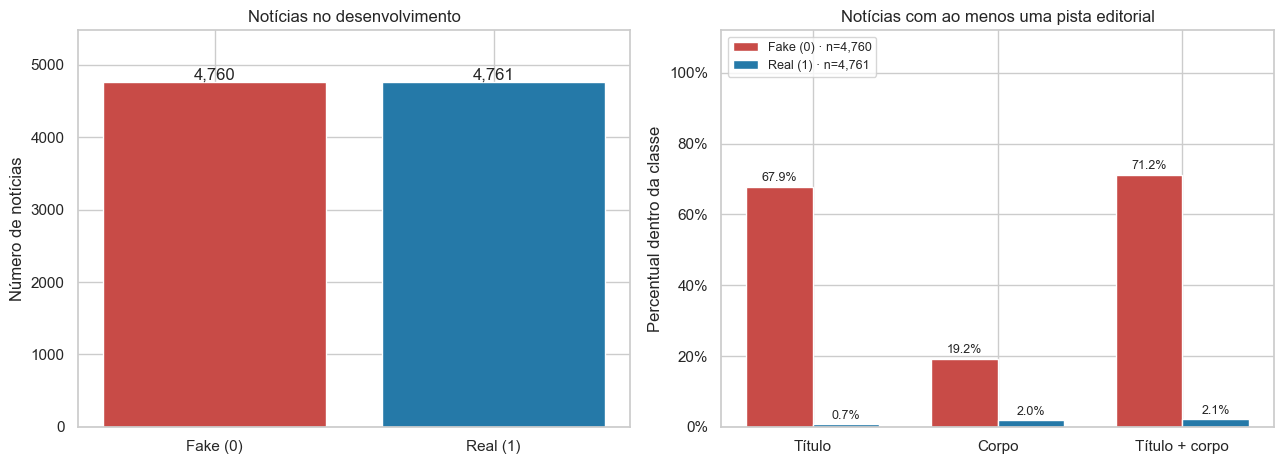

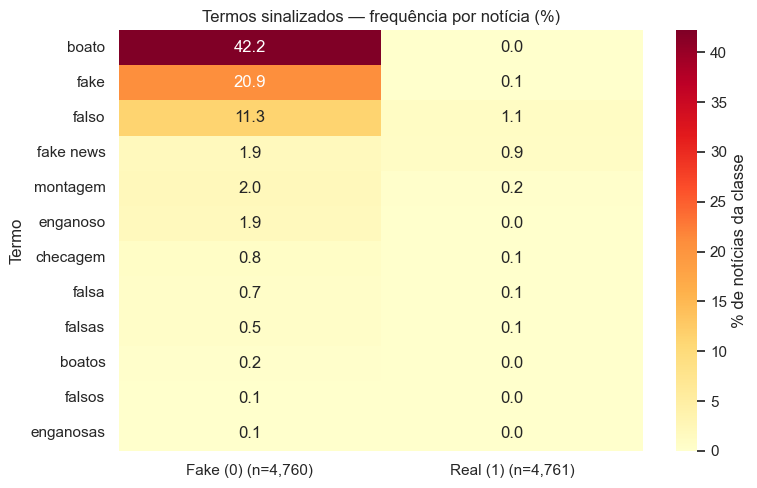

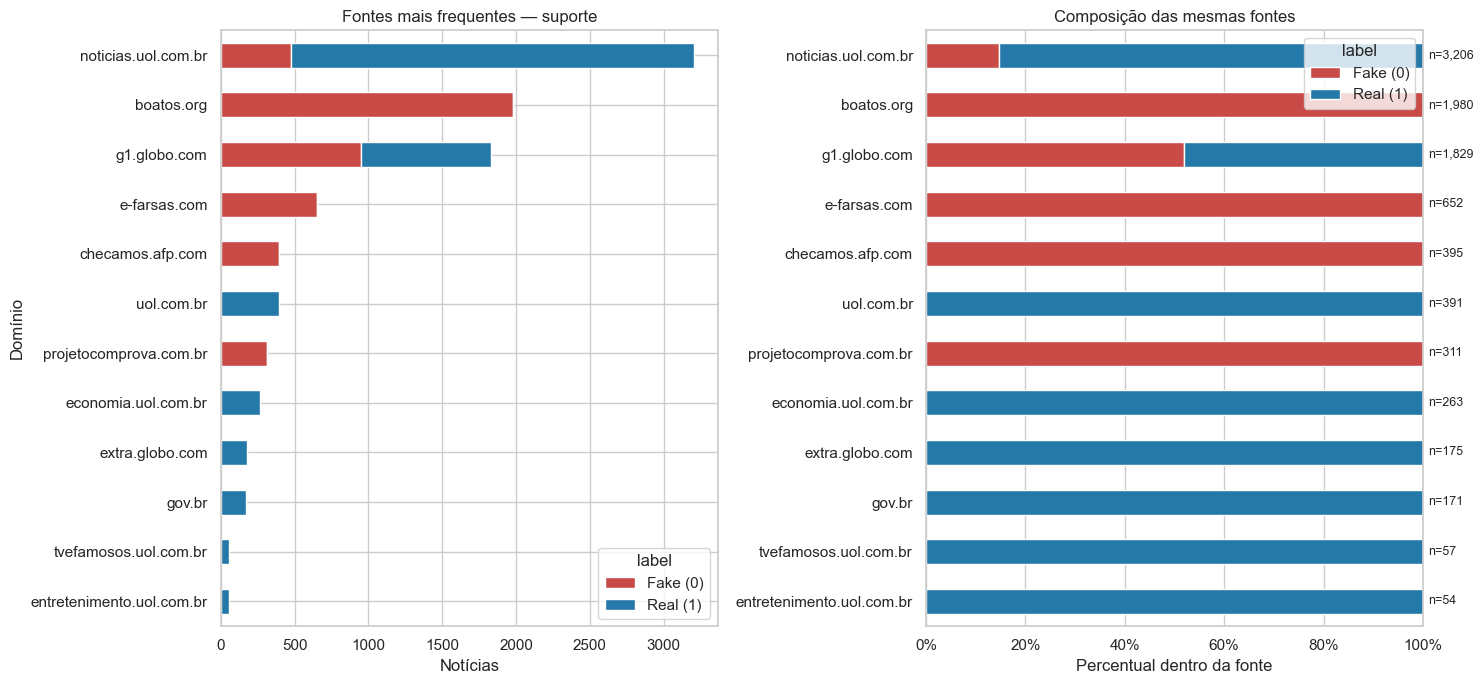

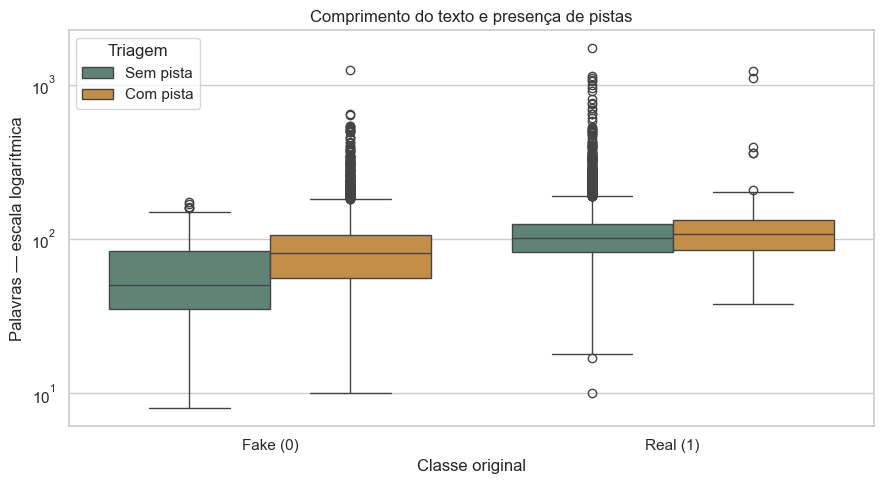

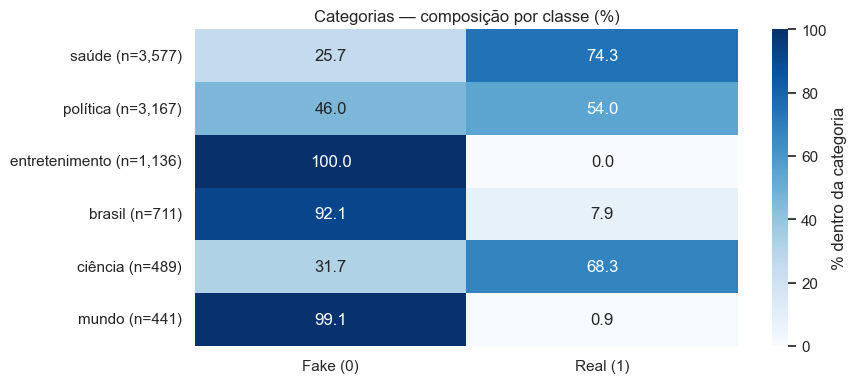

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
CLASS_ORDER = [0, 1]
CLASS_LABELS = {0: "Fake (0)", 1: "Real (1)"}
CLASS_COLORS = {0: "#c84b47", 1: "#2579a8"}
SALVAR_GRAFICOS = True
GRAPH_DIR = ROOT / "reports/auditoria_checagem/graficos"

def finish_figure(fig, name):
    fig.tight_layout()
    if SALVAR_GRAFICOS:
        GRAPH_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(GRAPH_DIR / f"{name}.png", dpi=180, bbox_inches="tight")
        fig.savefig(GRAPH_DIR / f"{name}.svg", bbox_inches="tight")
    plt.show()
    plt.close(fig)

# 1. Suporte e presença de pistas: denominador = número de notícias da classe.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
counts = audit.label.value_counts().reindex(CLASS_ORDER, fill_value=0)
axes[0].bar([CLASS_LABELS[k] for k in CLASS_ORDER], counts,
            color=[CLASS_COLORS[k] for k in CLASS_ORDER])
for i, count in enumerate(counts):
    axes[0].text(i, count, f"{count:,}", ha="center", va="bottom")
axes[0].set(title="Notícias no desenvolvimento", ylabel="Número de notícias")
axes[0].margins(y=0.15)
fields = ["pista_Titulo", "pista_Noticia", "pista_texto"]
rates = audit.groupby("label")[fields].mean().reindex(CLASS_ORDER)
x = np.arange(3)
for position, label in enumerate(CLASS_ORDER):
    values = rates.loc[label].to_numpy()
    bars = axes[1].bar(x + (position - 0.5) * 0.36, values, width=0.36,
                       label=f"{CLASS_LABELS[label]} · n={counts[label]:,}", color=CLASS_COLORS[label])
    for bar, value in zip(bars, values):
        axes[1].text(bar.get_x() + bar.get_width()/2, value + 0.015,
                     f"{value:.1%}", ha="center", fontsize=9)
axes[1].set_xticks(x, ["Título", "Corpo", "Título + corpo"])
axes[1].set(title="Notícias com ao menos uma pista editorial", ylabel="Percentual dentro da classe", ylim=(0, 1.12))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend(loc="upper left", fontsize=9)
finish_figure(fig, "01_classes_e_pistas")

# 2. Frequência documental: cada termo conta no máximo uma vez por notícia.
term_sets = audit.texto.map(lambda text: set(m.group(0).casefold() for m in re.finditer(PATTERN, str(text))))
term_counts = {}
for label in CLASS_ORDER:
    terms = term_sets[audit.label.eq(label)].explode().dropna()
    term_counts[label] = terms.value_counts()
term_table = pd.DataFrame(term_counts).fillna(0)
if not term_table.empty:
    top = term_table.sum(axis=1).nlargest(12).index
    percentages = term_table.loc[top].div(counts, axis=1) * 100
    percentages.columns = [f"{CLASS_LABELS[k]} (n={counts[k]:,})" for k in CLASS_ORDER]
    fig, ax = plt.subplots(figsize=(8, max(4, len(top)*0.42)))
    sns.heatmap(percentages, annot=True, fmt=".1f", cmap="YlOrRd", vmin=0,
                cbar_kws={"label": "% de notícias da classe"}, ax=ax)
    ax.set(title="Termos sinalizados — frequência por notícia (%)", xlabel="", ylabel="Termo")
    finish_figure(fig, "02_termos_por_classe")
else:
    print("Nenhum termo do padrão encontrado no desenvolvimento.")

# 3. Mesmas fontes nos dois painéis; seleção pelo volume total, sem consultar o teste.
domains = audit.dominio.replace("", "fonte não identificada")
source_counts = pd.crosstab(domains, audit.label).reindex(columns=CLASS_ORDER, fill_value=0)
top_sources = source_counts.sum(axis=1).nlargest(12).index
source_counts = source_counts.loc[top_sources].iloc[::-1]
source_rates = source_counts.div(source_counts.sum(axis=1), axis=0)
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
source_counts.rename(columns=CLASS_LABELS).plot.barh(stacked=True, ax=axes[0],
    color=[CLASS_COLORS[k] for k in CLASS_ORDER])
source_rates.rename(columns=CLASS_LABELS).plot.barh(stacked=True, ax=axes[1],
    color=[CLASS_COLORS[k] for k in CLASS_ORDER])
axes[0].set(title="Fontes mais frequentes — suporte", xlabel="Notícias", ylabel="Domínio")
axes[1].set(title="Composição das mesmas fontes", xlabel="Percentual dentro da fonte", ylabel="", xlim=(0, 1))
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
for i, total in enumerate(source_counts.sum(axis=1)):
    axes[1].text(1.01, i, f"n={total:,}", va="center", fontsize=9)
finish_figure(fig, "03_fontes_e_classes")

# 4. Distribuição do comprimento, sem suprimir textos longos.
length_data = pd.DataFrame({"classe": audit.label.map(CLASS_LABELS),
                           "palavras": audit.texto.str.split().str.len(),
                           "pista": audit.pista_texto.map({True: "Com pista", False: "Sem pista"})})
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=length_data, x="classe", y="palavras", hue="pista",
            order=[CLASS_LABELS[k] for k in CLASS_ORDER], ax=ax,
            palette={"Com pista": "#d89233", "Sem pista": "#598a78"})
ax.set_yscale("log")
ax.set(title="Comprimento do texto e presença de pistas", xlabel="Classe original", ylabel="Palavras — escala logarítmica")
ax.legend(title="Triagem")
finish_figure(fig, "04_comprimento_e_pistas")

# 5. Associação entre categoria e classe; não significa causalidade.
if "categoria_normalizada" in audit:
    categories = pd.crosstab(audit.categoria_normalizada, audit.label).reindex(columns=CLASS_ORDER, fill_value=0)
    categories = categories.loc[categories.sum(axis=1).nlargest(15).index]
    normalized = categories.div(categories.sum(axis=1), axis=0) * 100
    normalized.index = [f"{name} (n={int(categories.loc[name].sum()):,})" for name in categories.index]
    normalized.columns = [CLASS_LABELS[k] for k in CLASS_ORDER]
    fig, ax = plt.subplots(figsize=(9, max(4, len(categories)*0.4)))
    sns.heatmap(normalized, annot=True, fmt=".1f", vmin=0, vmax=100, cmap="Blues",
                cbar_kws={"label": "% dentro da categoria"}, ax=ax)
    ax.set(title="Categorias — composição por classe (%)", xlabel="", ylabel="")
    finish_figure(fig, "05_categorias_e_classes")


## 2. Ficha de revisão manual
Amostra estratificada por classe e presença de pistas. Leia título, corpo e fonte. Preencha: tipo de texto (alegação/checagem/misto), veredito explícito, disponibilidade no instante de previsão, identificação da alegação original, grupo de notícia, decisão e justificativa. Idealmente dois revisores independentes, com adjudicação das divergências. Não trate a classe como evidência da veracidade da notícia.

A amostra carrega as anotações da ficha completa quando disponíveis. A extração de alegações deve preservar contexto e ser rastreável; apagar palavras isoladas não transforma uma checagem em notícia original.

In [4]:
samples = []
for _, group in audit.groupby(["label", "pista_texto"]):
    samples.append(group.sample(n=min(25, len(group)), random_state=42))
review = pd.concat(samples).sort_values("id_original")[["id_original", "Titulo", "Noticia", "URL", "label", "pista_texto"]].copy()
for column in ["tipo_texto", "veredito_explicito", "disponivel_na_previsao", "alegacao_original",
               "grupo_noticia", "decisao", "justificativa", "revisor", "revisor_2", "adjudicacao"]:
    review[column] = ""
# Recupera as anotações da ficha preenchida; não reinicia as decisões.
filled_path = ROOT / "data/audit/v1_revisao_texto_autor.csv"
if filled_path.exists():
    filled = pd.read_csv(filled_path, keep_default_na=False).set_index("id_original")
    for column in ["tipo_texto", "veredito_explicito", "disponivel_na_previsao", "grupo_noticia",
                   "decisao", "justificativa", "revisor"]:
        if column in filled:
            review[column] = review.id_original.map(filled[column]).fillna("")
    if "alegacao_candidata" in filled:
        review["alegacao_original"] = review.id_original.map(filled["alegacao_candidata"]).fillna("")
    review = review.rename(columns={"alegacao_original": "alegacao_candidata"})
display(review.head(10))
EXPORTAR = False
if EXPORTAR:
    destination = ROOT / "reports/auditoria_checagem"
    destination.mkdir(parents=True, exist_ok=True)
    output = destination / "revisao_manual.csv"
    if output.exists():
        raise FileExistsError("Ficha existente: preserve as anotações ou escolha outro nome.")
    review.to_csv(output, index=False)


,id_original,Titulo,Noticia,URL,label,pista_texto,tipo_texto,veredito_explicito,disponivel_na_previsao,alegacao_original,grupo_noticia,decisao,justificativa,revisor,revisor_2,adjudicacao
198,198,"\n\nDecreto 9.715, de Bolsonaro, convoca homen...",querido amigo achar inevitável ocorrer o confr...,https://www.boatos.org/brasil/decreto-convoca-...,0,True,,,,,,,,,,
299,299,É #FAKE que Senegal usa cloroquina desde o pri...,circular rede social mensagem o senegal cloroq...,https://g1.globo.com/fato-ou-fake/coronavirus/...,0,True,,,,,,,,,,
604,604,Veja o que é #FATO ou #FAKE nas falas dos cand...,candidato disputar o prefeitura rir eduardo pa...,https://g1.globo.com/fato-ou-fake/noticia/2020...,0,True,,,,,,,,,,
680,680,enfermeiro desmaiar causar vacinar o coronavir...,o vídeo mostrar enfermeiro desmaiar receber o ...,https://www.e-farsas.com/enfermeira-desmaia-po...,0,False,,,,,,,,,,
793,793,Brasil ultrapassa a marca de 200 mil mortes po...,RIO — O Brasil ultrapassou na tarde desta quin...,https://extra.globo.com/noticias/coronavirus/b...,1,False,,,,,,,,,,
866,866,\n\nFachin cancelou crimes de Lázaro e Cármem ...,fachin cancelar o crime lázaro o crime descobr...,https://www.boatos.org/politica/fachin-cancelo...,0,True,,,,,,,,,,
919,919,\n\nCongresso e Senado censuraram vídeo da TV ...,o tv tarobá band apresentar vídeo hoje manhã s...,https://www.boatos.org/politica/congresso-sena...,0,True,,,,,,,,,,
956,956,Gráficos não comprovam que Brasil está próximo...,enganoso o publicação circular twitter afirmar...,https://noticias.uol.com.br/comprova/ultimas-n...,0,True,,,,,,,,,,
1048,1048,Vídeos de YouTube com informações falsas somam...,vídeo mentira d postar haver ano e somar milhã...,https://g1.globo.com/politica/noticia/2020/01/...,1,True,,,,,,,,,,
1073,1073,Fluxo de pessoas em lojas físicas sobe 194% em...,comparativo junho maio d ano haver aumentar mo...,https://economia.uol.com.br/noticias/estadao-c...,1,False,,,,,,,,,,


### Andamento da triagem e revisão contextual
Lê a ficha preenchida e distingue decisões de aprovação/exclusão, casos triados que requerem revisão contextual e registros sem decisão.


In [5]:
# A revisão manual completa não se confunde com a triagem automática.
review_path = ROOT / "data/audit/v1_revisao_texto_autor.csv"
if not review_path.exists():
    print("Ficha completa ainda não criada. Execute o carregamento do notebook 02 ou 03.")
    print("Nenhuma contaminação foi confirmada por revisão manual nesta seção.")
else:
    full_review = pd.read_csv(review_path, keep_default_na=False)
    required = {"id_original", "Classe", "decisao"}
    if not required.issubset(full_review.columns) or full_review.id_original.duplicated().any():
        raise ValueError("Ficha de revisão inválida: confira esquema e IDs.")
    full_review["Classe"] = validate_labels(full_review.Classe)
    # Exibe só IDs do desenvolvimento; não informa decisões sobre o reservado.
    progress_data = full_review.loc[full_review.id_original.isin(audit.id_original)].copy()
    if progress_data.empty:
        print("A ficha não tem IDs correspondentes ao desenvolvimento; confira sua origem.")
    else:
        decisions = progress_data.decisao.astype(str).str.strip().str.casefold()
        progress_data["status"] = decisions.map({"aprovar": "Aprovar (declarado)", "excluir": "Excluir (declarado)",
                                                       "revisar": "Triado — requer revisão contextual"}).fillna("Sem decisão/inválido")
        status = pd.crosstab(progress_data.Classe, progress_data.status).reindex(
            index=CLASS_ORDER, columns=["Aprovar (declarado)", "Excluir (declarado)",
                                             "Triado — requer revisão contextual", "Sem decisão/inválido"], fill_value=0)
        status.index = [CLASS_LABELS[k] for k in CLASS_ORDER]
        fig, ax = plt.subplots(figsize=(9, 4.8))
        status.plot.bar(stacked=True, ax=ax, color=["#598a78", "#c84b47", "#d3a34a", "#b6bdc5"], rot=0)
        ax.set(title="Ficha de auditoria — triagem e decisões no desenvolvimento", xlabel="Classe original", ylabel="Registros na ficha")
        ax.legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left")
        finish_figure(fig, "06_andamento_revisao")
        print("Triado não significa aprovado. Aprovar/excluir são decisões contextuais; revisar preserva a incerteza.")


Ficha completa ainda não criada. Execute o carregamento do notebook 02 ou 03.
Nenhuma contaminação foi confirmada por revisão manual nesta seção.


## 3. Notícias relacionadas e duplicatas aproximadas
A deduplicação exata não encontra paráfrases. Os pares abaixo são candidatos para revisão, não grupos automaticamente validados. Use IDs de origem da coleta e de geração de resumos quando disponíveis. Todas as variantes de uma notícia devem permanecer no mesmo fold; revise também possíveis relações com o conjunto reservado antes da avaliação final, sem usar seu desempenho para selecionar o método.

In [6]:
from sklearn.neighbors import NearestNeighbors
# Limite para inspeção interativa. Para auditoria completa, aumente após estimar o custo.
subset = audit.head(2000)
vec = TfidfVectorizer(preprocessor=normalize_text, max_features=30000)
matrix = vec.fit_transform(subset.texto)
if len(subset) > 1:
    neighbors = NearestNeighbors(n_neighbors=min(3, len(subset)), metric="cosine", algorithm="brute").fit(matrix)
    distances, indices = neighbors.kneighbors(matrix)
    pairs = {}
    for i, (ds, js) in enumerate(zip(distances, indices)):
        for distance, j in zip(ds, js):
            if i != j and 1 - distance >= 0.85:
                key = tuple(sorted([int(subset.iloc[i].id_original), int(subset.iloc[j].id_original)]))
                pairs[key] = float(1 - distance)
    display(pd.DataFrame([{"id_a": a, "id_b": b, "similaridade": score} for (a, b), score in pairs.items()]))


,id_a,id_b,similaridade
0,62,7754,0.857569
1,11063,11066,0.892389
2,7333,11063,0.853114
3,5016,10184,0.935717
4,3995,9693,0.962442
5,855,8008,0.878468
6,40,43,0.894622
7,4361,4362,0.916217
8,7333,11066,0.879381
9,7333,7336,0.870112


## 4. Ablation study apenas no desenvolvimento
Compare texto completo, título, corpo e remoção exploratória das pistas usando exatamente os mesmos folds. Os escores de CV são exploratórios e não substituem o holdout. O experimento só executa quando ativado e após informar grupos de notícia revisados. A remoção de pistas pode eliminar informação legítima; uma queda de desempenho não prova causalidade.

Faça também um teste por domínio: ele verifica transferência entre fontes, mas pode ter folds com classes ausentes. Registre suporte por classe e a viabilidade antes de interpretar os resultados.

In [7]:
EXECUTAR_EXPERIMENTOS = False
# Preencha com IDs reais de alegações/notícias após revisão; não use um ID distinto por linha
# para contornar o agrupamento de variantes.
GRUPOS_REVISADOS = None  # pd.Series: índice = audit.index; valor = grupo_noticia
if EXECUTAR_EXPERIMENTOS:
    if GRUPOS_REVISADOS is None:
        raise ValueError("Informe grupos revisados antes dos experimentos.")
    groups = GRUPOS_REVISADOS.reindex(audit.index)
    if groups.isna().any() or groups.nunique() < 5:
        raise ValueError("Grupos incompletos ou insuficientes.")
    variants = {"completo": audit.texto, "titulo": audit.Titulo.fillna(""),
                "corpo": audit.Noticia.fillna(""),
                "sem_pistas": audit.texto.str.replace(PATTERN, " ", regex=True)}
    splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    folds = list(splitter.split(audit.texto, audit.label, groups))
    for tr, va in folds:
        if audit.label.iloc[tr].nunique() < 2 or audit.label.iloc[va].nunique() < 2:
            raise ValueError("Fold sem as duas classes; revise a estratégia.")
    results = []
    for name, texts in variants.items():
        estimator = Pipeline([("tfidf", TfidfVectorizer(preprocessor=normalize_text,
                            max_features=50000, ngram_range=(1, 2))),
                              ("clf", LinearSVC(C=1.0, random_state=42, max_iter=5000))])
        scores = cross_validate(estimator, texts, audit.label, cv=folds,
                                scoring=["f1_macro", "balanced_accuracy"], error_score="raise")
        results.append({"entrada": name, "f1_macro": scores["test_f1_macro"].mean(),
                        "desvio_f1": scores["test_f1_macro"].std(),
                        "balanced_accuracy": scores["test_balanced_accuracy"].mean()})
    display(pd.DataFrame(results))


## 5. Critérios para concluir a auditoria

- Documentar origem, licença, período e tratamentos anteriores de cada base.
- Quantificar checagens, alegações e textos mistos com exemplos e decisões dos revisores.
- Resolver conflitos de rótulos e agrupar notícias/variantes antes da separação.
- Excluir metadados e vereditos indisponíveis no instante de previsão, com regra documentada.
- Comparar versões do texto somente no desenvolvimento; congelar a regra escolhida.
- Avaliar uma vez no holdout e em base independente por fonte/período; registrar classes e suporte.
- Não apresentar acurácia em checagens como capacidade comprovada de verificar fatos.

### Registro da conclusão (preencher após execução e revisão)
Fonte e hash da base: …
Amostras revisadas e concordância: …
Proporção de texto pós-checagem: …
Grupos e duplicatas resolvidos: …
Regra final de entrada: …
Limitações e decisões: …

Os resultados anteriores da v1 não são recalculados nem alterados por este notebook.

## Resultados da triagem executada em 08/10/2026

Triagem automática: **11.902 registros**. Revisão contextual inicial: **10** (7 fontes acessíveis, 3 falhas de acesso). Seis registros recuperáveis e quatro duvidosos. Não é revisão completa nem amostra aleatória. Os demais permanecem pendentes; os gráficos de pistas não equivalem a vereditos humanos. Consulte reports/auditoria_checagem/relatorio_triagem_2026-10-08.md. Não treine nem conclua desempenho a partir apenas dos seis aprovados.


In [8]:
import json
triage_file = ROOT / "reports/auditoria_checagem/triagem_textos_2026-10-08.csv"
summary_file = ROOT / "reports/auditoria_checagem/resumo_triagem_2026-10-08.json"
if triage_file.exists() and summary_file.exists():
    executed_triage = pd.read_csv(triage_file, keep_default_na=False)
    print(json.loads(summary_file.read_text(encoding="utf-8")))
    display(executed_triage.loc[executed_triage.status_fonte.ne("nao_consultada"),
        ["id_original", "url", "status_fonte", "status_revisao", "observacao"]])
else:
    print("Arquivos desta rodada de triagem não encontrados.")


{'date': '2026-10-08', 'n': 11902, 'method': 'Triagem automática integral, revisão contextual inicial de 10 registros selecionados por ordem; não é amostra aleatória.', 'triage': {'marcador_editorial_explicito': 3648, 'sem_sinal_nao_equivale_aprovacao': 6059, 'fonte_checagem_sem_marcador': 1382, 'termo_ambiguo': 676, 'veredito_candidato_exige_contexto': 137}, 'source': {'consultada': 7, 'falha_acesso': 3, 'nao_consultada': 11892}, 'review': {'recuperavel': 6, 'duvidoso': 4, 'pendente': 11892}, 'review_sheet_updates': 6, 'review_pending': 11896, 'limitations': ['Termos sinalizados não confirmam contaminação.', 'Candidatos de título/subtítulo não são aprovados automaticamente.', 'Texto Noticia já está normalizado na base; consulta não restaura conteúdo ausente.', 'Autoria do checador não é usada como autoria original.', 'Fontes de todos os demais registros ainda não foram consultadas.']}


,id_original,url,status_fonte,status_revisao,observacao
0,0,https://www.boatos.org/religiao/papa-francisco...,consultada,recuperavel,Fonte distingue mensagem circulante e desmenti...
1,1,https://noticias.uol.com.br/internacional/ulti...,falha_acesso,duvidoso,Falha da ferramenta ao abrir a URL; texto loca...
2,2,https://www.uol.com.br/nossa/noticias/afp/2020...,consultada,recuperavel,Fonte AFP/UOL confirma reportagem e autoria da...
3,3,https://economia.uol.com.br/noticias/reuters/2...,consultada,recuperavel,Fonte Reuters/UOL confirma reportagem atribuíd...
4,4,https://www.e-farsas.com/as-parciais-das-eleic...,consultada,duvidoso,Fonte contém alegação específica e conclusão e...
5,5,https://www.boatos.org/mundo/macron-mandou-pol...,consultada,recuperavel,Fonte apresenta versões da mensagem circulante...
6,6,https://noticias.uol.com.br/internacional/ulti...,falha_acesso,duvidoso,Falha na consulta à fonte. Ausência de sinais ...
7,7,https://www.boatos.org/tecnologia/programa-ren...,consultada,recuperavel,Fonte identifica mensagem de cadastro comparti...
8,8,https://g1.globo.com/ciencia-e-saude/noticia/2...,falha_acesso,duvidoso,Falha de acesso à fonte; manter pendente sem a...
9,9,https://www.boatos.org/saude/vacina-contra-cov...,consultada,recuperavel,Fonte separa mensagem circulante e análise pos...
